In [1]:
# Project setup
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Imports

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

from src.data.loaders import PointsDataset
from src.visualization.visualization_utils import create_meshgrid
from src.visualization.feature_space_plots import plot_in_rectangular_coordinates, PlotManager
from src.models.logistic_regression import train_logistic_regression
from src.visualization.decision_boundaries import plot_decision_boundary
from src.evaluation.metrics import ModelMetrics
from src.features.transformations import cartesian_to_polar, cartesian_to_elliptic

# Data Loading

In [3]:
current_dir = Path.cwd()

# Load the dataset
data_path = current_dir.parent / "data" / "raw" / "points.json"
dataset = PointsDataset.from_json(data_path=data_path)

# Print essential statistics
print('- Number of positive points:', len(dataset.y[dataset.y==1]))
print('- Number of negative points:', len(dataset.y[dataset.y==0]))
print('- Total number of points:', len(dataset.y[dataset.y==1]) + len(dataset.y[dataset.y==0]))

# Preview dataframe
print('- Predictors shape:', dataset.X.shape, 'Predictions shape:', dataset.y.shape)

# Data as single dataframe
df = pd.concat([dataset.X, dataset.y], axis=1)
print('\n- Dataframe info:')
print(df.info())
print('\n- Dataframe preview:')
print(df.head())
print('\n- Dataframe describe:')
print(df.describe())

- Number of positive points: 50
- Number of negative points: 49
- Total number of points: 99
- Predictors shape: (99, 2) Predictions shape: (99,)

- Dataframe info:
<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       99 non-null     float64
 1   y       99 non-null     float64
 2   label   99 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 2.4 KB
None

- Dataframe preview:
          x         y  label
0 -1.173217  0.870813      0
1  0.754003  0.392344      1
2  0.375546  1.665072      0
3 -0.381368 -0.803828      1
4  0.666667  1.894737      0

- Dataframe describe:
               x          y      label
count  99.000000  99.000000  99.000000
mean    0.014791  -0.012566   0.505051
std     1.003884   1.003415   0.502519
min    -1.924309  -2.153110   0.000000
25%    -0.733624  -0.822967   0.000000
50%    -0.020378  -0.019139   1.000000
75%     0.75

Distribution of values suggesting plotting should be safe, simple and visually informative.

# Plotting

In [4]:
PLOT_CONFIG = {
    "show": True,
    "save": True,
    "out_dir": current_dir.parent / "results" / "figures"
}

plot_manager = PlotManager(PLOT_CONFIG)

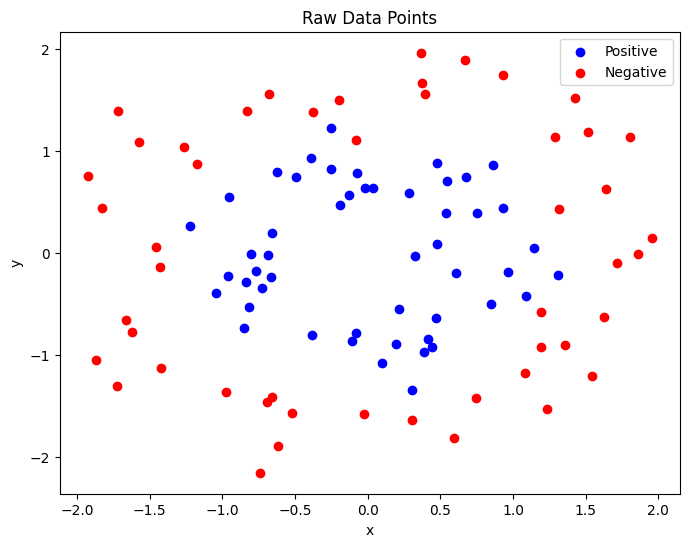

In [5]:
raw_data_fig, raw_data_ax = plot_in_rectangular_coordinates(dataset.X, dataset.y, title='Raw Data Points')
plot_manager.handle(raw_data_fig, name='raw_data')
display(raw_data_fig)

# Initial Data Observations

- There are 99 points, split virtually even among the two classes.
    - Data size is relatively small.
- Data does not seem sparse.
- A standard linear classifier will likely fail in the Cartesian coordinate space, but the structure suggests that an appropriate transformation could simplify the problem.
    - Positive points are noticeably closer to a point than are negative ones. In this representation, that point is the origin.
    - The coordinate axes are close to being axes of symmetry for the data points, implying some degree of angular symmetry. 
- The decision boundary resembles an ellipse
    - Radial distance from the origin alone appears to be the most important relevant feature
- Radial and angular coordinates would be a more natural choice for this system
- The classification proble could be linear in polar and/or elliptical coordinates

# Prepare Data for Modelling

Set up Cartesian grid for decision boundary evaluation and visualization.

In [6]:
# Create a Cartesian meshgrid to plot decision boundaries
grid_x, grid_y, grid_cartesian = create_meshgrid(dataset.X)

# Logistic Regression Attempt on Raw Data

Evaluate whether a linear model is sufficient in raw feature space.

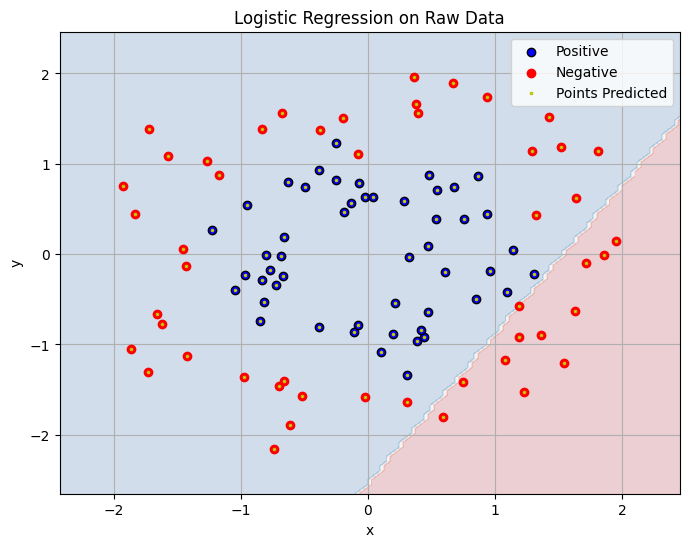

,model,dataset,accuracy,precision,recall,f1
0,Logistic Regression,Cartesian,0.616162,0.568182,1.0,0.724638


In [7]:
lr_model = train_logistic_regression(dataset.X, dataset.y)

fig, ax = plot_decision_boundary(
    model=lr_model, X=dataset.X, y=dataset.y,
    prediction_domain=grid_cartesian, grid_x=grid_x, grid_y=grid_y,
    title='Logistic Regression on Raw Data'
)

display(fig)

lr_metrics = ModelMetrics('Logistic Regression', 'Cartesian', dataset.y, lr_model.predict(dataset.X))
lr_metrics.compute_metrics()
lr_metrics.to_pandas()

Performance suggests strong non-linearity in decision boundary.

# Feature Transformation: Polar Coordinates

Test whether radial symmetry enables separability.

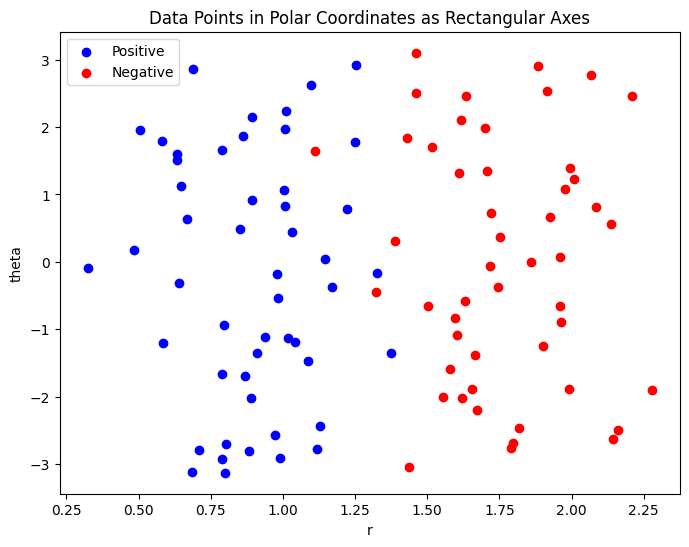

In [8]:
# Transform data points into polar form
polar_dataset = dataset.transform(cartesian_to_polar)

# Plotting data points in polar coordinates (but as rectangular axes)
polar_data_fig, polar_data_ax = plot_in_rectangular_coordinates(polar_dataset.X, polar_dataset.y, title='Data Points in Polar Coordinates as Rectangular Axes', axis_x='r', axis_y='theta')
plot_manager.handle(polar_data_fig, name='polar_data_rectangular')
display(polar_data_fig)

The classes become approximately separable along the radial axis, suggesting that a linear model may suffice in this representation.

# Feature Transformation: Elliptical Coordinates

Test whether elliptical symmetry enables more separability.

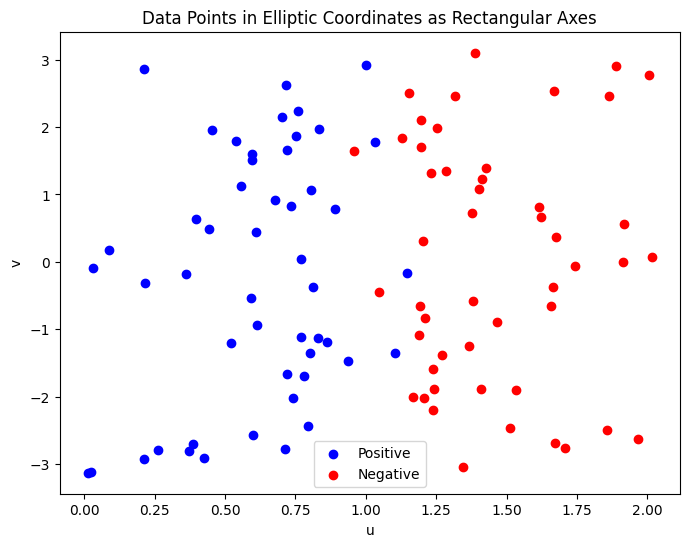

In [9]:
# Transform data points into polar form
elliptic_dataset = dataset.transform(cartesian_to_elliptic)

# Plotting data points in polar coordinates (but as rectangular axes)
elliptic_data_fig, elliptic_data_ax = plot_in_rectangular_coordinates(elliptic_dataset.X, elliptic_dataset.y, title='Data Points in Elliptic Coordinates as Rectangular Axes', axis_x='u', axis_y='v')
plot_manager.handle(elliptic_data_fig, name='elliptic_data_rectangular')
display(elliptic_data_fig)

The decision boundary also looks close to a straight line in these elliptical coordinates, very similar to what is obtained in the polar representation.

# Logistic Regression on Polar Coordinates

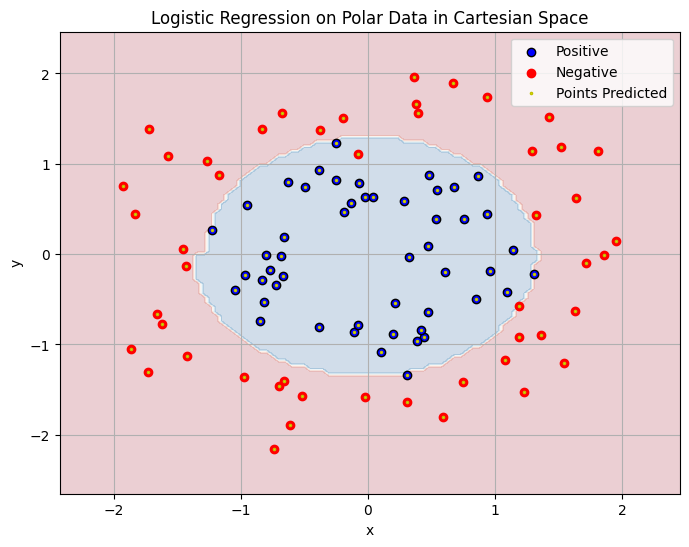

,model,dataset,accuracy,precision,recall,f1
0,Logistic Regression,Polar,0.969697,0.960784,0.98,0.970297


In [11]:
lr_polar_model = train_logistic_regression(polar_dataset.X, polar_dataset.y)

# Transform meshgrid into polar grid
grid_polar = cartesian_to_polar(grid_x.ravel(), grid_y.ravel())

fig, ax = plot_decision_boundary(
    model=lr_polar_model, X=dataset.X, y=dataset.y,
    prediction_domain=grid_polar, grid_x=grid_x, grid_y=grid_y,
    title='Logistic Regression on Polar Data in Cartesian Space'
)

display(fig)

lr_polar_metrics = ModelMetrics('Logistic Regression', 'Polar', polar_dataset.y, lr_polar_model.predict(polar_dataset.X))
lr_polar_metrics.compute_metrics()
lr_polar_metrics.to_pandas()

# Logistic Regression on Elliptic Coordinates

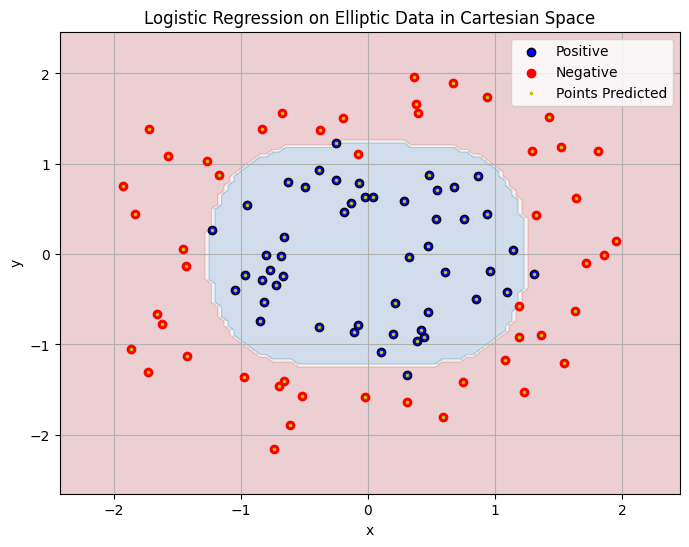

,model,dataset,accuracy,precision,recall,f1
0,Logistic Regression,Elliptic,0.959596,0.979167,0.94,0.959184


In [12]:
lr_elliptic_model = train_logistic_regression(elliptic_dataset.X, elliptic_dataset.y)

# Use the standard meshgrid to plot decision boundaries
grid_u = np.arccosh((1/(2*1)) * (np.sqrt((grid_x**2 + 1**2)**2 + grid_y**2) + np.sqrt((grid_x**2 - 1**2)**2 + grid_y**2)))
grid_v = np.arctan2(grid_y, grid_x)
grid_elliptic = pd.DataFrame({'u': grid_u.ravel(), 'v': grid_v.ravel()})

fig, ax = plot_decision_boundary(
    model=lr_elliptic_model, X=dataset.X, y=dataset.y,
    prediction_domain=grid_elliptic, grid_x=grid_x, grid_y=grid_y,
    title='Logistic Regression on Elliptic Data in Cartesian Space'
)

display(fig)

lr_elliptic_metrics = ModelMetrics('Logistic Regression', 'Elliptic', elliptic_dataset.y, lr_elliptic_model.predict(elliptic_dataset.X))
lr_elliptic_metrics.compute_metrics()
lr_elliptic_metrics.to_pandas()

# Evaluating Feature Importance of Polar Coordinates

- Mutual information
- Univariate and bivariate model comparisons
- Perturbation test

# Model Comparison Framework

5-fold cross-validation

# Logistic Regression on Polar Coordinates

# A More Complex Model: Support Vector Machines

# Logistic Regression on Polar Coordinates Pt. 2

Parametric equation of an ellipse (t as the angle): x(t) = a • cos(t), y(t) = b • sin(t)

Distance from origin: r(t) = a^2 • cos^2(t) + b^2 • sin^2(t)

Linearized kernel for logistic regression: r(t) = a^2 • cos^2(t) + b^2 • (1 - cos^2(t)) = (b^2) + (a^2 - b^2) cos^2(t) satisfies natural kernel form a' + b'X under naturally engineered variable X=cos^2(t)

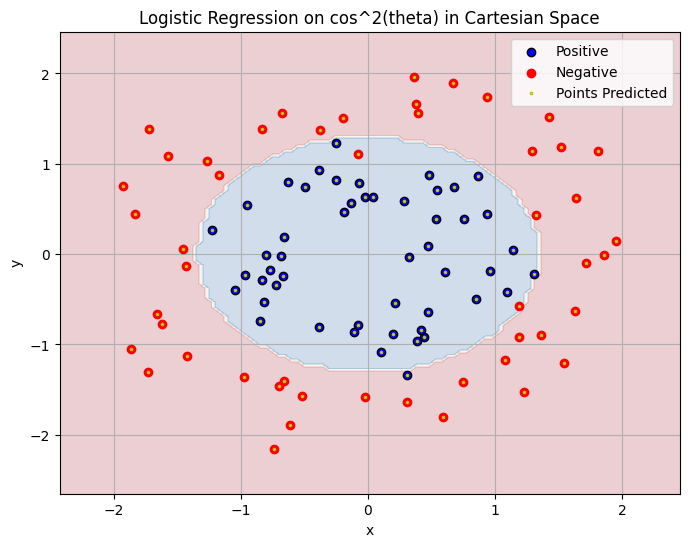

,model,dataset,accuracy,precision,recall,f1
0,Logistic Regression,cos^2(theta),0.969697,0.960784,0.98,0.970297


In [26]:
cos_sq_dataset = PointsDataset(
    pd.DataFrame({'r': polar_dataset.X['r'], 'cos^2(theta)': np.cos(polar_dataset.X['theta'])**2}), polar_dataset.y
)
grid_cos_sq = pd.DataFrame({ 'r': grid_polar['r'], 'cos^2(theta)': np.cos(grid_polar['theta'])**2})

lr_cos_sq_model = train_logistic_regression(cos_sq_dataset.X, cos_sq_dataset.y)

fig, ax = plot_decision_boundary(
    model=lr_cos_sq_model, X=dataset.X, y=dataset.y,
    prediction_domain=grid_cos_sq, grid_x=grid_x, grid_y=grid_y,
    title='Logistic Regression on cos^2(theta) in Cartesian Space'
)

display(fig)

lr_cos_sq_metrics = ModelMetrics('Logistic Regression', 'cos^2(theta)', cos_sq_dataset.y, lr_cos_sq_model.predict(cos_sq_dataset.X))
lr_cos_sq_metrics.compute_metrics()
lr_cos_sq_metrics.to_pandas()

In [22]:
cos_sq_dataset.X

,cos^2(theta)
0,0.644776
1,0.786929
2,0.048407
3,0.183736
4,0.110162
...,...
94,0.675779
95,0.099306
96,0.707245
97,0.466778


# Non-linear Logistic Regression: Polar Logistic Regression

# Custom Parametric Model

# Cross-Validation Results

- Statistical significance